In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive, so that we can load peper image

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Define SNR and MSE for Evaluation

In [ ]:
import numpy as np

def snr_dB(actu,pred):
    err = pred.astype(np.float32) - actu.astype(np.float32)
    sigma_n = np.var(err)
    sigma_s = np.var(actu.astype(np.float32))
    ns = sigma_s/sigma_n
    snr = np.mean(10 * np.log10(ns))
    return snr

def MSE(actu, pred):
     return np.square(actu - pred).mean()

#Load Peper image and plot it

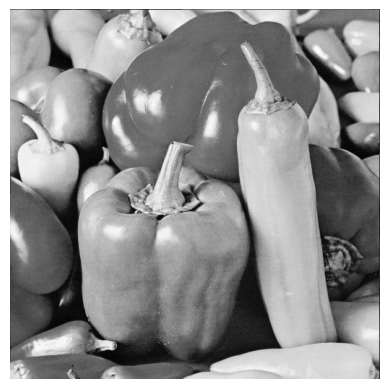

In [ ]:
# import packages
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = sio.loadmat(work_path + 'Data/Peppers.mat')['peppers']

# plot image
plt.imshow(img,cmap='gray')
plt.axis('off');


# Perform 2D Hadamard Transform

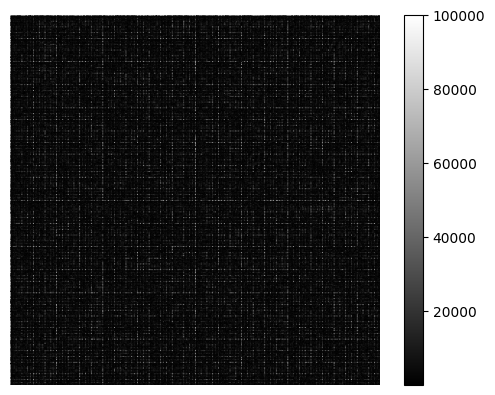

In [ ]:
from sympy import fwht, ifwht

# perform Hadamard transform column-wise and then row-wise
img_fwht_tmp = fwht(img)
img_fwht = fwht(np.array(img_fwht_tmp).T)
img_fwht=np.array(img_fwht).astype('float32')

# plot Hadamard coefficients
im=plt.imshow(np.abs(img_fwht), cmap='gray', vmax = 100000)
plt.colorbar(im)
plt.axis('off')

# Perform Inverse 2D-Hadamard

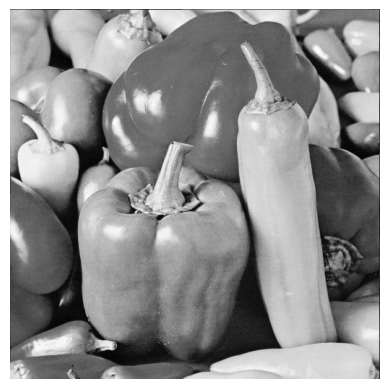

In [ ]:
# perform Hadamard transfor column-wise and then row-wise
img_ifwht_tmp = ifwht(img_fwht)
img_ifwht = fwht(np.array(img_ifwht_tmp).T)
img_ifwht=np.array(img_ifwht).astype('float32')

# plot image
plt.imshow(img,cmap='gray')
plt.axis('off');

# Perform 2D Hadamard Transform using Blocks and Threshold

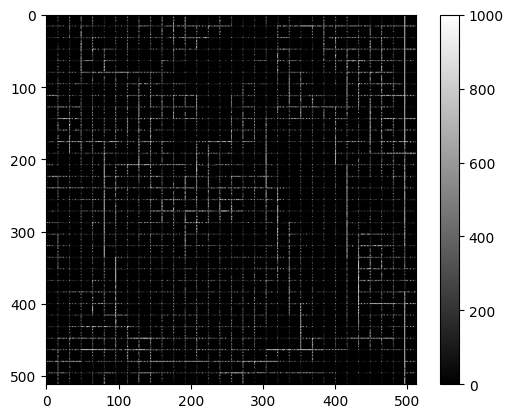

In [ ]:
from sympy import fwht, ifwht

wht_coeff = np.zeros((img.shape))

block_size = 16

for i in range(0, img.shape[0], block_size):
  for j in range(0, img.shape[1], block_size):
    img_tmp = img[i:i+block_size, j:j+block_size]

    # perform Hadamard transfor column-wise and then row-wise
    img_fwht_tmp = fwht(img_tmp)
    img_fwht = fwht(np.array(img_fwht_tmp).T)

    wht_coeff[i:i+block_size, j:j+block_size] = np.array(img_fwht).astype('float32')

    # if only retain top-left coefficient for each block
    wht_coeff[i+2:i+block_size, j+2:j+block_size] = 0


# plot log scale of Hadamard coefficients
im=plt.imshow(np.abs(wht_coeff), cmap='gray', vmax = 1000)
plt.colorbar(im)

# Perform Inverse 2D Hadamard Transform using 8x8 Blocks

SNR: 11.75
MSE: 869.54


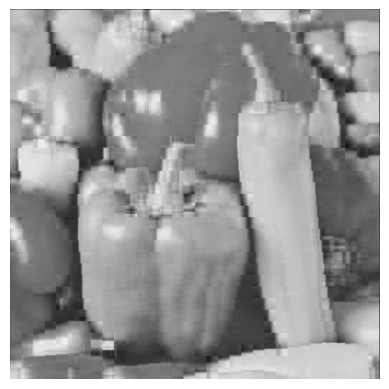

In [ ]:
import cv2

# take 2D-iDCT
img_iwht = np.zeros((wht_coeff.shape))
block_size = 16

for i in range(0, wht_coeff.shape[0], block_size):
  for j in range(0, wht_coeff.shape[1], block_size):
    img_tmp = wht_coeff[i:i+block_size, j:j+block_size]

    # perform inverse Hadamard transfor column-wise and then row-wise
    img_ifwht_tmp = ifwht(img_tmp)
    img_ifwht = ifwht(np.array(img_ifwht_tmp).T)

    img_iwht[i:i+block_size, j:j+block_size] = np.array(img_ifwht).astype('float32')

# convert to uint8
norm_image = cv2.normalize(img_iwht, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_32F)
plt.figure()
plt.imshow(norm_image.astype(np.uint8), cmap='gray')
plt.axis('off');

# print SNR and MSE
print('SNR:', np.round(snr_dB(img, norm_image),2))
print('MSE:', np.round(MSE(img, norm_image), 2))

# Load Dog Image



(np.float64(-0.5), np.float64(735.5), np.float64(991.5), np.float64(-0.5))

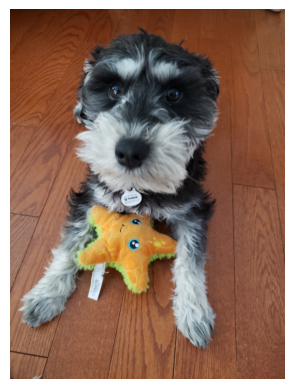

In [ ]:
# load dog image
from matplotlib import image
import numpy as np
import cv2

# load image
img = image.imread(work_path + 'Data/Dog.jpg')
img = np.transpose(img, (0,1,2))

# because FWHT requires the number of sample points to be a power of 2, we resize image
img = cv2.resize(img, (736, 992))
# plot image
import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')


# Perform 2D-Hadamard Transform with Block and Threshold

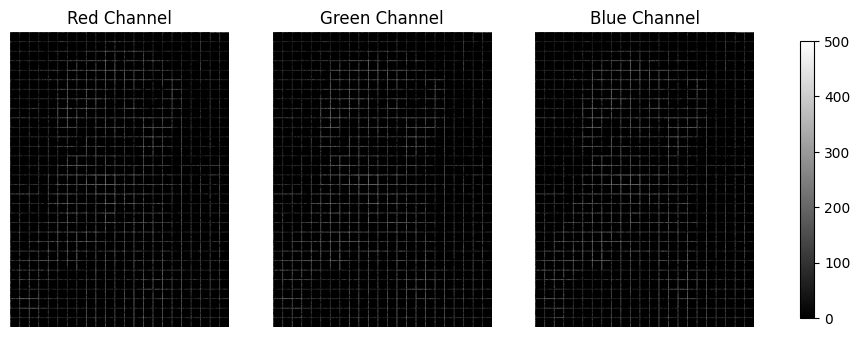

In [ ]:
from sympy import fwht, ifwht

wht_coeff = np.zeros((img.shape))

block_size = 32

for i in range(0, img.shape[0], block_size):
  for j in range(0, img.shape[1], block_size):
      for c in range(3):
        img_tmp = img[i:i+block_size, j:j+block_size, c]

        # perform Hadamard transfor column-wise and then row-wise
        img_fwht_tmp = fwht(img_tmp)
        img_fwht = fwht(np.array(img_fwht_tmp).T)

        wht_coeff[i:i+block_size, j:j+block_size, c] = np.array(img_fwht).astype('float32')

        # if only retain top-left coefficient for each block
        wht_coeff[i+2:i+block_size, j+2:j+block_size] = 0

fig, ax = plt.subplots(1, 3, figsize=(12, 8))
im= ax[0 ].imshow(np.abs(wht_coeff[:,:,0]),cmap='gray', vmax = 500)
ax[0].set_title('Red Channel')
ax[0].axis('off')

im = ax[1].imshow(np.abs(wht_coeff[:,:,1]),cmap='gray', vmax = 500)
ax[1].set_title('Green Channel')
ax[1].axis('off')

im = ax[2].imshow(np.abs(wht_coeff[:,:,2]),cmap='gray', vmax = 500)
ax[2].set_title('Blue Channel')
ax[2].axis('off')

fig.colorbar(im, ax=ax.ravel().tolist(), shrink = 0.45)

# Perform Inverse 2D-Hadamard Transform Block-Wise

SNR: 10.56
MSE: 246.28


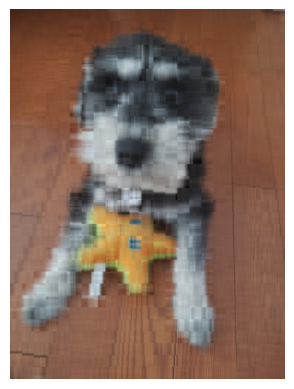

In [ ]:
from sympy import fwht, ifwht
import cv2

img_iwht = np.zeros((wht_coeff.shape))

block_size = 32

for i in range(0, img.shape[0], block_size):
  for j in range(0, img.shape[1], block_size):
      for c in range(3):
        img_tmp = wht_coeff[i:i+block_size, j:j+block_size, c]

        # perform Hadamard transfor column-wise and then row-wise
        img_ifwht_tmp = ifwht(img_tmp)
        img_ifwht = ifwht(np.array(img_ifwht_tmp).T)

        img_iwht[i:i+block_size, j:j+block_size, c] = np.array(img_ifwht).astype('float32')


# convert to uint8
norm_image = cv2.normalize(img_iwht, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_32F)
plt.figure()
plt.imshow(norm_image.astype(np.uint8))
plt.axis('off');

# print SNR and MSE
print('SNR:', np.round(snr_dB(img, norm_image),2))
print('MSE:', np.round(MSE(img, norm_image), 2))